---
# ✳️ Keyness y Dispersión Textual
---

Los conceptos de **keyness** y **dispersión textual** permiten analizar el lenguaje desde dos perspectivas complementarias:

- Qué términos son característicos de un grupo de textos.
- Cómo se distribuyen esos términos a lo largo del corpus.

---

### 🔑 Keyness

El análisis de *keyness* identifica las palabras que son **estadísticamente más características o distintivas** de un grupo de documentos en comparación con otro.

Se basa en diferencias de frecuencia entre grupos y puede utilizar estadísticas como:

- **Chi-cuadrado**.
- **Log-likelihood ratio**.

Este tipo de análisis permite detectar términos que aparecen con una frecuencia inusualmente alta en un grupo respecto de otro.

Aplicaciones comunes:

- Comparar discursos por autor, partido político, medio de comunicación o período histórico.
- Identificar vocabulario ideológicamente marcado.
- Detectar términos distintivos entre grupos temáticos o experimentales.
- Explorar diferencias léxicas entre categorías de documentos.

---

### 📍 Dispersión textual

La **dispersión textual** describe cómo se distribuye una palabra o expresión a lo largo de un corpus.

Una palabra puede ser muy frecuente, pero aparecer concentrada en pocos documentos o en una sección específica del corpus. En cambio, otra palabra puede tener una frecuencia menor, pero estar distribuida de manera más uniforme.

Este análisis permite:

- Distinguir términos ampliamente utilizados de términos concentrados en pocos documentos.
- Identificar vocabulario central y periférico.
- Detectar patrones temporales o posicionales en el uso de determinadas palabras.
- Evaluar la consistencia de un término a lo largo del corpus.

---

### ⚖️ Dos perspectivas complementarias

- **Keyness** responde:  
  > ¿Qué palabras permiten diferenciar estadísticamente un grupo de otro?

- **Dispersión textual** responde:  
  > ¿Dónde aparecen esas palabras y cuán ampliamente están distribuidas?

> 📌 En esta unidad aprenderemos primero a identificar y visualizar estos patrones mediante métodos estadísticos implementados en `quanteda`. Más adelante veremos cómo un **LLM** puede ayudarnos a interpretar y contextualizar los resultados obtenidos.

In [42]:
# Esto se demora aprox. 20 minutos

install.packages("quanteda")
install.packages("quanteda.textmodels")
install.packages("quanteda.textstats")
install.packages("quanteda.textplots")


The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpKzGICd/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpKzGICd/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpKzGICd/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpKzGICd/downloaded_packages


In [43]:
library("quanteda.textmodels")
library("quanteda.textplots")
library("quanteda.textstats")
library("quanteda")


## ⚙️ Habilitar cómputo paralelo en Quanteda con `data.table`

El paquete `quanteda` puede aprovechar el **cómputo paralelo** para acelerar operaciones pesadas (como la construcción de `dfm`, tokenización, etc.), pero para ello requiere el soporte del paquete **`data.table`**.

---

### ✅ Pasos para habilitarlo

1. Instala `data.table` (solo una vez):
   - `install.packages("data.table")`

2. Carga el paquete en tu sesión:
   - `library(data.table)`

Una vez cargado, `quanteda` detectará automáticamente su presencia y activará el procesamiento paralelo cuando sea posible.

---

### 📌 ¿Cómo saber si está activado?

Usar las funciones *setDTthreads()* y *getDTthreads()*  



In [44]:

install.packages("data.table")  
library(data.table)



The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpKzGICd/downloaded_packages


In [45]:
setDTthreads(16)        # Usa 16 núcleos 
getDTthreads()          # Verifica cuántos núcleos están activos


[1] 16

---
---

## I. Críticas de Cine

En esta unidad trabajaremos con el clásico corpus de reseñas de películas de **Pang & Lee (2004)**, una de las colecciones de datos más utilizadas en investigación sobre **Procesamiento de Lenguaje Natural (NLP)**.

Cada reseña posee una etiqueta que indica si la crítica original publicada en **IMDb** fue **positiva** (`pos`) o **negativa** (`neg`), según la calificación otorgada por el autor.

---

## 🎬  ¿Qué es IMDb?

**IMDb (Internet Movie Database)** es una de las bases de datos cinematográficas más importantes del mundo. Contiene información sobre películas, series, actores, directores y millones de reseñas escritas por usuarios.

---

### 🧾 Características del corpus

- **2.000 reseñas** de películas.
- Idioma: **inglés**.
- Corpus **balanceado**:
  - 1.000 reseñas positivas.
  - 1.000 reseñas negativas.

---

### 🎯 ¿Por qué utilizaremos este corpus?

En esta unidad emplearemos este conjunto de datos para responder preguntas como:

- ¿Qué palabras caracterizan las reseñas positivas?
- ¿Qué palabras son distintivas de las reseñas negativas?
- ¿Cómo se distribuyen esos términos a lo largo del corpus?

Estas preguntas constituyen el objetivo central del análisis de **keyness** y **dispersión textual**, que desarrollaremos a continuación.

> 📌 **Idea clave:** En esta unidad utilizaremos las etiquetas *positiva* y *negativa* únicamente para comparar grupos de documentos mediante **keyness**. El objetivo no es construir un clasificador de sentimientos, sino identificar el vocabulario característico de cada grupo.

## 🔍 Explorar el corpus

Al igual que en cualquier análisis de datos, el primer paso consiste en **familiarizarse con el conjunto de información** antes de aplicar métodos estadísticos o modelos más sofisticados.

En NLP ocurre exactamente lo mismo: antes de calcular frecuencias, analizar *keyness* o entrenar modelos, es recomendable inspeccionar el corpus para comprender su estructura, tamaño y contenido general.

En las siguientes celdas exploraremos algunos documentos del corpus y verificaremos sus principales características antes de comenzar el análisis.

In [46]:
print(data_corpus_moviereviews)

Corpus consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
"plot : two teen couples go to a church party , drink and the..."

cv001_19502.txt :
"the happy bastard's quick movie review  damn that y2k bug . ..."

cv002_17424.txt :
"it is movies like these that make a jaded movie viewer thank..."

cv003_12683.txt :
" " quest for camelot " is warner bros . ' first feature-leng..."

cv004_12641.txt :
"synopsis : a mentally unstable man undergoing psychotherapy ..."

cv005_29357.txt :
"capsule : in 2176 on the planet mars police taking into cust..."

[ reached max_ndoc ... 1,994 more documents ]


---
### 🗂️ Explorando las variables documentales

Antes de comenzar el análisis, es conveniente inspeccionar las **variables documentales** (*docvars*) asociadas al corpus.

El siguiente comando:

```r
head(docvars(data_corpus_moviereviews))
```

muestra las primeras observaciones de los metadatos asociados a cada reseña.

---

### 📌 ¿Qué información contienen?

En este corpus encontraremos principalmente:

- **`id1`** e **`id2`**: identificadores del documento.
- **`sentiment`**: etiqueta que indica si la reseña es **positiva** (`"pos"`) o **negativa** (`"neg"`).

Estas variables documentales nos permitirán comparar distintos grupos de documentos a lo largo de la unidad.

En particular, utilizaremos la variable **`sentiment`** para identificar las palabras más características de las reseñas positivas y negativas mediante análisis de **keyness**.

> 📌 **Idea clave:** Las **docvars** contienen información descriptiva sobre los documentos y permiten definir los grupos que posteriormente compararemos mediante técnicas como **keyness**.

In [47]:
head(docvars(data_corpus_moviereviews))

,sentiment,id1,id2
,<fct>,<chr>,<chr>
1,neg,cv000,29416
2,neg,cv001,19502
3,neg,cv002,17424
4,neg,cv003,12683
5,neg,cv004,12641
6,neg,cv005,29357


### 📊 Distribución de las etiquetas de sentimiento

Antes de comparar ambos grupos de reseñas, es conveniente verificar cómo se distribuyen las etiquetas de **sentimiento** en el corpus.

El siguiente comando:

```r
table(docvars(data_corpus_moviereviews)$sentiment)
```

extrae la variable `sentiment` de las **docvars** y construye una tabla de frecuencias con el número de reseñas **positivas** (`"pos"`) y **negativas** (`"neg"`).

---

### 📌 ¿Por qué es importante?

Conocer la distribución de las clases es un paso habitual del **Análisis Exploratorio de Datos (EDA)**.

En este caso, verificaremos que el corpus está **balanceado**, es decir, contiene el mismo número de reseñas positivas y negativas.

Esto facilita la comparación entre ambos grupos y permite interpretar los resultados del análisis de **keyness** sin que las diferencias observadas se deban simplemente a un desbalance en el número de documentos de cada categoría.

> 📌 **Idea clave:** Antes de comparar grupos de documentos, es recomendable verificar cuántos documentos pertenecen a cada categoría. En este corpus, las etiquetas de sentimiento definen los grupos que posteriormente analizaremos mediante **keyness**.

In [48]:
table(docvars(data_corpus_moviereviews)$sentiment)


 neg  pos 
1000 1000 

In [49]:
head(summary(data_corpus_moviereviews), 20)

,Text,Types,Tokens,Sentences,sentiment,id1,id2
,<chr>,<int>,<int>,<int>,<fct>,<chr>,<chr>
1,cv000_29416.txt,354,841,9,neg,cv000,29416
2,cv001_19502.txt,156,278,1,neg,cv001,19502
3,cv002_17424.txt,276,553,3,neg,cv002,17424
4,cv003_12683.txt,314,558,2,neg,cv003,12683
5,cv004_12641.txt,380,841,2,neg,cv004,12641
6,cv005_29357.txt,328,749,1,neg,cv005,29357
7,cv006_17022.txt,331,641,5,neg,cv006,17022
8,cv007_4992.txt,325,674,6,neg,cv007,4992
9,cv008_29326.txt,441,794,10,neg,cv008,29326


---
### ⚠️ Posibles problemas de codificación (UTF-8)

En algunos computadores (especialmente cuando se utilizan distintos sistemas operativos o configuraciones regionales) pueden aparecer advertencias relacionadas con la **codificación de caracteres**, por ejemplo:

```text
strings not representable in native encoding will be translated to UTF-8
```

En la mayoría de los casos, este mensaje es **solo una advertencia** y **no afecta la ejecución del código**.

---

### ✅ Si el texto se visualiza correctamente

Si los acentos, la letra **ñ**, los símbolos y los emojis se muestran correctamente, **puede ignorar la advertencia** y continuar trabajando normalmente.

---

### ⚠️ Si aparecen caracteres extraños

Si observa caracteres como:

```text
Ã¡   Ã±   ???   �
```

o el código produce errores relacionados con la codificación, revise la configuración de UTF-8 de su sistema y de R/RStudio.

Los siguientes recursos oficiales muestran cómo resolver estos problemas según el sistema operativo:

- 📖 **R Installation and Administration – Internationalization & Locales:** :contentReference[oaicite:0]{index=0}
- 💻 **UTF-8 Support on Windows (R Project):** :contentReference[oaicite:1]{index=1}

---

> 📌 **Recomendación:** Guarde siempre sus scripts y archivos **R Markdown/Jupyter** utilizando la codificación **UTF-8**, ya que es el estándar utilizado actualmente por R, Python y la mayoría de las herramientas de procesamiento de lenguaje natural.

In [50]:
Sys.setlocale("LC_CTYPE", "en_US.UTF-8") # For Mac users, set locale to UTF-8

[1] "en_US.UTF-8"

---
## 🖨️ Visualización de textos con `cat()`

La función `cat()` en R se utiliza para **concatenar e imprimir objetos** de forma continua, sin saltos de línea innecesarios ni comillas. Es especialmente útil cuando queremos visualizar el contenido **completo de un documento textual** dentro del corpus, como una reseña individual.

---

### 🔍 ¿Por qué usar `cat()` con un corpus?

Cuando se intenta imprimir directamente un documento de un corpus (por ejemplo, `data_corpus_moviereviews[5]`) sin `cat()`, R suele mostrar un resumen estructurado del objeto, no su contenido real.




In [51]:
data_corpus_moviereviews[5]

Corpus consisting of 1 document and 3 docvars.
cv004_12641.txt :
"synopsis : a mentally unstable man undergoing psychotherapy ..."

In [52]:
data_corpus_moviereviews[5] %>%
  cat()

synopsis : a mentally unstable man undergoing psychotherapy saves a boy from a potentially fatal accident and then falls in love with the boy's mother , a fledgling restauranteur . 
unsuccessfully attempting to gain the woman's favor , he takes pictures of her and kills a number of people in his way . 
comments : stalked is yet another in a seemingly endless string of spurned-psychos-getting-their-revenge type movies which are a stable category in the 1990s film industry , both theatrical and direct-to-video . 
their proliferation may be due in part to the fact that they're typically inexpensive to produce ( no special effects , no big name stars ) and serve as vehicles to flash nudity ( allowing them to frequent late-night cable television ) . 
stalked wavers slightly from the norm in one respect : the psycho never actually has an affair ; on the contrary , he's rejected rather quickly ( the psycho typically is an ex-lover , ex-wife , or ex-husband ) . 
other than that , stalked is ju

Como es de esperarse, despúes de ese comentario, el *review* es negativo.

In [53]:
docvars(data_corpus_moviereviews[5])

sentiment,id1,id2
<fct>,<chr>,<chr>
neg,cv004,12641


---
## ✂️ Tokenización y construcción de la DFM

Una vez explorado el corpus, el siguiente paso consiste en **tokenizar los documentos** y construir una **Document-Feature Matrix (DFM)**.

La tokenización divide cada reseña en unidades más pequeñas (*tokens*), mientras que la DFM transforma esas unidades en una representación numérica que permite comparar las frecuencias de las palabras entre reseñas positivas y negativas.

En esta etapa aplicaremos algunas transformaciones habituales del NLP tradicional:

- Eliminación de signos de puntuación.
- Eliminación de *stopwords*.
- Conversión a minúsculas.

Estas decisiones de preprocesamiento influirán directamente en los resultados posteriores del análisis de **keyness**.

> 📌 **Idea clave:** El análisis de *keyness* se realiza sobre la DFM. Por ello, la calidad de la comparación depende de cómo se tokenizan y preparan previamente los textos.

In [54]:
movie_toks <- tokens(data_corpus_moviereviews, remove_punct = TRUE,) %>%
                     tokens_remove(pattern = stopwords("en")) %>%
                     tokens_tolower()
print(movie_toks)


Tokens consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
 [1] "plot"     "two"      "teen"     "couples"  "go"       "church"  
 [7] "party"    "drink"    "drive"    "get"      "accident" "one"     
[ ... and 333 more ]

cv001_19502.txt :
 [1] "happy"     "bastard's" "quick"     "movie"     "review"    "damn"     
 [7] "y2k"       "bug"       "got"       "head"      "start"     "movie"    
[ ... and 118 more ]

cv002_17424.txt :
 [1] "movies"    "like"      "make"      "jaded"     "movie"     "viewer"   
 [7] "thankful"  "invention" "timex"     "indiglo"   "watch"     "based"    
[ ... and 252 more ]

cv003_12683.txt :
 [1] "quest"          "camelot"        "warner"         "bros"          
 [5] "first"          "feature-length" "fully-animated" "attempt"       
 [9] "steal"          "clout"          "disney's"       "cartoon"       
[ ... and 259 more ]

cv004_12641.txt :
 [1] "synopsis"      "mentally"      "unstable"      "man"          
 [5] "undergoing"    "psychother

In [55]:
movie_dfm <- dfm(movie_toks)
print(movie_dfm)
head(docvars(movie_dfm))


Document-feature matrix of: 2,000 documents, 47,932 features (99.44% sparse) and 3 docvars.
                 features
docs              plot two teen couples go church party drink drive get
  cv000_29416.txt    1   2    4       1  2      1     1     1     1   3
  cv001_19502.txt    0   0    0       0  0      0     0     0     0   1
  cv002_17424.txt    2   1    0       0  2      0     0     0     0   0
  cv003_12683.txt    0   0    0       0  0      0     0     0     0   0
  cv004_12641.txt    1   1    0       0  0      0     0     0     0   0
  cv005_29357.txt    1   0    0       0  0      0     0     0     0   0
[ reached max_ndoc ... 1,994 more documents, reached max_nfeat ... 47,922 more features ]


,sentiment,id1,id2
,<fct>,<chr>,<chr>
1,neg,cv000,29416
2,neg,cv001,19502
3,neg,cv002,17424
4,neg,cv003,12683
5,neg,cv004,12641
6,neg,cv005,29357


---
## 💬 Separando las reseñas positivas y negativas

El análisis de **keyness** consiste en comparar **dos grupos de documentos** para identificar las palabras que son estadísticamente más características de cada uno.

En este ejemplo, utilizaremos la variable documental **`sentiment`** para dividir la **Document-Feature Matrix (DFM)** en dos subconjuntos:

- Reseñas **positivas** (`"pos"`).
- Reseñas **negativas** (`"neg"`).

Posteriormente compararemos ambos grupos para determinar qué términos distinguen a las reseñas positivas de las negativas.

---

### 🛠️ ¿Cómo se realiza la separación?

`quanteda` dispone de funciones específicas para seleccionar subconjuntos según el tipo de objeto con el que se esté trabajando:

- `corpus_subset()` para objetos **`corpus`**.
- `tokens_subset()` para objetos **`tokens`**.
- `dfm_subset()` para objetos **`dfm`**.

Como el análisis de **keyness** se realizará sobre la **DFM**, utilizaremos la función **`dfm_subset()`** para crear las matrices correspondientes a las reseñas positivas y negativas.

> 📌 **Idea clave:** El análisis de **keyness** compara grupos de documentos representados mediante una **DFM**. En este caso, utilizaremos `dfm_subset()` para separar las reseñas positivas y negativas según la variable documental **`sentiment`**.

In [56]:
pos_dfm <- dfm_subset(movie_dfm, sentiment == "pos")
neg_dfm <- dfm_subset(movie_dfm, sentiment == "neg")

In [57]:
print(pos_dfm)
head(docvars(pos_dfm))

Document-feature matrix of: 1,000 documents, 47,932 features (99.41% sparse) and 3 docvars.
                 features
docs              plot two teen couples go church party drink drive get
  cv000_29590.txt    0   0    0       0  1      0     0     0     0   2
  cv001_18431.txt    4   1    0       0  0      0     0     0     2   0
  cv002_15918.txt    0   3    0       0  0      0     1     0     0   0
  cv003_11664.txt    0   0    0       0  0      0     0     0     0   1
  cv004_11636.txt    1   2    0       0  2      0     0     0     0   0
  cv005_29443.txt    0   3    0       0  1      0     1     0     0   1
[ reached max_ndoc ... 994 more documents, reached max_nfeat ... 47,922 more features ]


,sentiment,id1,id2
,<fct>,<chr>,<chr>
1,pos,cv000,29590
2,pos,cv001,18431
3,pos,cv002,15918
4,pos,cv003,11664
5,pos,cv004,11636
6,pos,cv005,29443


¿Cuáles son los *topfeatures* en cada uno de estos dfms?

In [58]:
print(topfeatures(pos_dfm, 15))

      film        one      movie       like       just      story       also 
      4872       2908       2393       1719       1339       1214       1200 
      good       even       time        can       much  character characters 
      1193       1175       1171       1149       1026       1013        986 
      life 
       983 


In [59]:
print(topfeatures(neg_dfm, 15))

     film     movie       one      like      just      even      good      time 
     4002      3053      2618      1836      1562      1381      1130      1112 
      can       get       bad      much     story character      plot 
     1084      1038      1021       998       905       895       876 


Podríamos también utilizado la función *textstat_frequency()*:

In [60]:
textstat_frequency(movie_dfm, n = 15, groups = sentiment)

,feature,frequency,rank,docfreq,group
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,film,4002,1,843,neg
2,movie,3053,2,797,neg
3,one,2618,3,862,neg
4,like,1836,4,759,neg
5,just,1562,5,685,neg
6,even,1381,6,670,neg
7,good,1130,7,573,neg
8,time,1112,8,599,neg
9,can,1084,9,606,neg


---
## 📊 ¿Por qué no basta con analizar las palabras más frecuentes?

Al aplicar `textstat_frequency()` al `movie_dfm`, agrupando las reseñas según su **sentimiento**, observamos que muchas de las palabras más frecuentes aparecen tanto en las reseñas **positivas** como en las **negativas**.

Entre ellas encontramos términos como:

> `film`, `movie`, `one`, `like`, `just`, `story`, `character`, ...

Estas palabras describen el tema general del corpus (críticas de cine), pero **no necesariamente distinguen** entre ambos grupos.

---

### 🤔 ¿Por qué ocurre esto?

Las etiquetas **positiva** (`"pos"`) y **negativa** (`"neg"`) corresponden a una **variable documental** (*docvar*) asignada a cada reseña a partir de la calificación original de IMDb.

Por lo tanto, el hecho de que una reseña sea positiva o negativa **no implica que utilice un vocabulario completamente distinto**. Ambos grupos hablan sobre películas, actores, guiones, personajes y escenas, por lo que comparten una gran cantidad de términos.

---

### 🎯 La necesidad de un análisis de *keyness*

Las tablas de frecuencia responden a preguntas como:

> **¿Cuáles son las palabras más frecuentes de cada grupo?**

Sin embargo, muchas veces la pregunta realmente interesante es:

> **¿Qué palabras distinguen estadísticamente un grupo del otro?**

Responder esta segunda pregunta requiere un análisis de **keyness**, que compara las frecuencias relativas entre grupos para identificar los términos verdaderamente característicos de cada uno.

> 📌 **Idea clave:** Las palabras más frecuentes no siempre son las más informativas. El análisis de **keyness** permite identificar aquellas palabras que diferencian estadísticamente un grupo de documentos respecto de otro.

---


## II. Keyness

## 🗝️ **textstat_keyness()**

La función `textstat_keyness()` se utiliza para calcular la **importancia relativa** de las palabras en un conjunto de documentos frente a otro conjunto de referencia. Esta importancia se expresa a través de una métrica llamada **keyness**, que permite identificar las palabras **más distintivas** o características de un grupo de textos en comparación con otro.

---

### 📌 ¿Qué mide?

El análisis de *keyness* no se basa únicamente en la frecuencia absoluta de las palabras, sino en **cómo su distribución difiere entre grupos**. Entre las métricas más comunes para este cálculo se encuentran:

- **Log-likelihood ratio** (por defecto en `quanteda`)
- **Chi-cuadrado**
- **Frecuencia Relativa Ponderada**

---

### 🧠 ¿Para qué sirve?

- Detectar vocabulario que distingue dos categorías (por ejemplo, reseñas positivas vs. negativas)
- Comparar el discurso de distintos autores, partidos, medios o períodos históricos
- Identificar términos ideológicamente cargados o representativos

---

### 🔗 Más información

Explicación introductoria aquí: [Keyness - Alvin Leung, NTNU](https://alvinntnu.github.io/NTNU_ENC2036_LECTURES/keyword-analysis.html)

---

> ✅ `textstat_keyness()` es una herramienta fundamental para ir más allá del conteo de palabras y entender **qué palabras realmente diferencian grupos de documentos** dentro de un corpus.


In [61]:
tstat_key_movies <- textstat_keyness(movie_dfm, target = docvars(movie_dfm, "sentiment") == "pos")

head(tstat_key_movies, n= 10)
class(tstat_key_movies)

,feature,chi2,p,n_target,n_reference
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,life,114.32855,0.000000e+00,983,487
2,jackie,85.27958,0.000000e+00,210,47
3,truman,79.37566,0.000000e+00,121,11
4,great,69.31432,1.110223e-16,744,396
5,mulan,67.32265,2.220446e-16,79,1
6,war,63.26963,1.776357e-15,259,90
7,world,53.07539,3.209655e-13,624,341
8,excellent,52.83604,3.625988e-13,146,37
9,shrek,52.39701,4.534151e-13,59,0


[1] "keyness"    "textstat"   "data.frame"

## 🔑 Análisis de Keyness en críticas de cine

Utilizamos la función `textstat_keyness()` para identificar las palabras que son estadísticamente más características de las críticas **positivas** en el corpus de Pang & Lee (2004).

Se define como grupo objetivo (`target`) aquellas reseñas cuyo valor en la variable `sentiment` es igual a `"pos"` (positivo). El análisis compara la frecuencia de palabras en este grupo frente al grupo de referencia (críticas negativas).

---

### 📊 Resultados

El resultado almacenado en `tstat_key_movies` es un **data.frame** que contiene, para cada término:

- El valor estadístico de *keyness* (por defecto, log-likelihood ratio)
- La frecuencia del término en cada grupo
- La dirección de asociación (positiva o negativa)

Este tipo de análisis permite identificar qué palabras tienden a aparecer con mayor probabilidad en las reseñas **positivas** versus las **negativas**, aportando información útil para tareas de clasificación o interpretación semántica.

---

> ✅ El objeto resultante es de clase `data.frame`, lo que facilita su inspección, visualización y exportación.


## 🧮 Ejemplo: Cálculo del Chi-cuadrado (χ²) a partir de una tabla de contingencia

El test de **Chi-cuadrado** se utiliza para determinar si existe una asociación estadísticamente significativa entre dos variables categóricas. En el análisis de keyness, nos permite evaluar si una palabra ocurre con una frecuencia significativamente diferente entre dos grupos de textos.

---

### 📊 Supongamos esta tabla de contingencia:

|                | Aparece la palabra | No aparece la palabra | Total |
|----------------|--------------------|------------------------|-------|
| Grupo Positivo | 30                 | 70                     | 100   |
| Grupo Negativo | 10                 | 90                     | 100   |
| **Total**      | 40                 | 160                    | 200   |

---

### 📐 Paso 1: Calcular frecuencias esperadas

Para cada celda, usamos:

> **Esperado = (fila × columna) / total**

Por ejemplo, para la celda "Grupo Positivo - Aparece":

> (100 × 40) / 200 = 20

La tabla esperada sería:

|                | Esperado (Aparece) | Esperado (No aparece) |
|----------------|--------------------|------------------------|
| Grupo Positivo | 20                 | 80                     |
| Grupo Negativo | 20                 | 80                     |

---



### 🧮 Paso 2: Cálculo del Chi-cuadrado (χ²)

El estadístico se calcula con la fórmula:

$$
\chi^2 = \sum \frac{(\text{observado} - \text{esperado})^2}{\text{esperado}}
$$

Ejemplo de cálculo:

$$
\chi^2 = \frac{(30 - 20)^2}{20} + \frac{(70 - 80)^2}{80} + \frac{(10 - 20)^2}{20} + \frac{(90 - 80)^2}{80}
$$

$$
\chi^2 = \frac{100}{20} + \frac{100}{80} + \frac{100}{20} + \frac{100}{80} = 5 + 1.25 + 5 + 1.25 = \boxed{12.5}
$$


---

### 🧠 Interpretación

Este valor de χ² se compara con un valor crítico de la distribución χ² con **1 grado de libertad**. Si supera dicho valor (por ejemplo, 3.84 para un nivel de significancia de 0.05), se concluye que hay **una diferencia significativa** en la presencia de la palabra entre ambos grupos.

---

> ✅ Este procedimiento es la base del análisis estadístico de keyness con pruebas como el log-likelihood y el chi-cuadrado.


### ℹ️ ¿Por qué el Chi-cuadrado usa \((r - 1)(c - 1)\) grados de libertad?

Cuando se aplica el test de Chi-cuadrado a una **tabla de contingencia**, los grados de libertad (df) se calculan como:

$$
df = (r - 1) \times (c - 1)
$$

donde:
- \( r \): número de filas
- \( c \): número de columnas

---

### 🎯 ¿Cuál es la lógica detrás?

La idea es que, si se **conocen los totales marginales** (sumas por fila y columna), no todas las celdas pueden variar libremente.

Al llenar la tabla:
- Puedes elegir valores libremente solo en **\((r - 1)(c - 1)\)** celdas.
- El resto de las celdas quedan **automáticamente determinadas** para que se cumplan los totales.

---

### 📊 Ejemplo: Tabla 2x2

|                | A       | B       | Total fila |
|----------------|---------|---------|------------|
| Grupo 1        | ?       | ?       | 100        |
| Grupo 2        | ?       | ?       | 100        |
| **Total col**  | 40      | 160     | 200        |

- Si se fija el valor de una celda (por ejemplo, Grupo 1 - A), los otros tres valores se calculan automáticamente.
- Por eso, **solo 1 celda es libre** → \( df = 1 \).

---

### ✅ Generalización

En cualquier tabla de tamaño $r \times c$, con totales marginales conocidos, solo **\((r - 1)(c - 1)\)** celdas pueden variar libremente antes de que el resto quede determinado.

Este número es exactamente el **grado de libertad** del test Chi-cuadrado.

---

> 🧠 **Conclusión**: Los grados de libertad miden cuánta "libertad" tiene la tabla para variar antes de que las frecuencias esperadas queden completamente determinadas.


## 📊 Visualización de palabras clave con `textplot_keyness()`

La función `textplot_keyness()` permite representar visualmente los resultados obtenidos con `textstat_keyness()`. Específicamente, muestra las palabras más distintivas de un grupo de textos frente a otro, ordenadas según su valor estadístico (por ejemplo, log-likelihood o chi-cuadrado).

---

### 🎨 Interpretación del gráfico

- El eje horizontal muestra el **estadístico de keyness**.
- El eje vertical contiene las **palabras más distintivas**.
- Los colores indican la **asociación** con cada grupo:
  - En este caso, `darkblue` representa palabras asociadas a críticas **positivas**.
  - `red` representa palabras asociadas a críticas **negativas**.

---

Este gráfico permite identificar visualmente qué términos caracterizan cada grupo, lo cual es útil tanto para análisis exploratorios como para comunicar resultados.

> ✅ Este tipo de visualización es especialmente útil cuando se trabaja con datos de texto etiquetados, como análisis de sentimiento o clasificación temática.


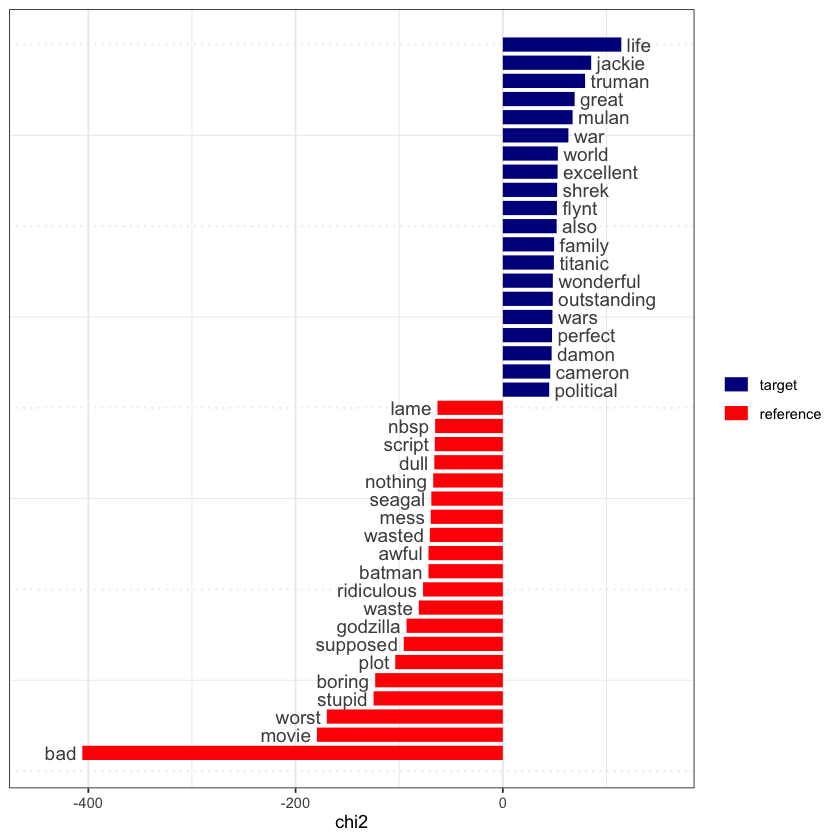

In [62]:
textplot_keyness(tstat_key_movies,color = c("darkblue", "red"))

---
## 💾 Exportar resultados de *keyness* para analizarlos con un LLM en Python

Para interpretar estos resultados con un LLM, lo más simple es **exportar la tabla `tstat_key_movies` a un archivo CSV** y luego cargarla en un notebook de Python (por ejemplo, con `pandas`).

Esto evita tener que llamar a una API de LLM directamente desde R y te permite usar tu flujo de trabajo habitual en Python (por ejemplo, `anthropic`, `openai`, o cualquier librería de tu preferencia).

> 📌 El archivo se guardará en el directorio de trabajo actual de R (`getwd()`). Ajusta la ruta si prefieres guardarlo en otra carpeta.

In [63]:
# Exportamos la tabla de keyness a CSV para analizarla luego en Python

if (!requireNamespace("readr", quietly = TRUE)) install.packages("readr")
library(readr)

write_csv(tstat_key_movies, "tstat_key_movies.csv")

getwd()  # Confirma dónde quedó guardado el archivo

[1] "/Users/fernandodiaz/Dropbox/Semana Internacional 2026/Codes"

In [64]:
?textplot_keyness()

textplot_keyness      package:quanteda.textplots       R Documentation

_P_l_o_t _w_o_r_d _k_e_y_n_e_s_s

_D_e_s_c_r_i_p_t_i_o_n:

     Plot the results of a "keyword" of features comparing their
     differential associations with a target and a reference group,
     after calculating keyness using
     ‘quanteda.textstats::textstat_keyness()’.

_U_s_a_g_e:

     textplot_keyness(
       x,
       show_reference = TRUE,
       show_legend = TRUE,
       n = 20L,
       min_count = 2L,
       margin = 0.05,
       color = c("darkblue", "gray"),
       labelcolor = "gray30",
       labelsize = 4,
       font = NULL
     )
     
_A_r_g_u_m_e_n_t_s:

       x: a return object from ‘quanteda.textstats::textstat_keyness()’

show_reference: logical; if ‘TRUE’, show key reference features in
          addition to key target features

show_legend: logical; if ‘TRUE’, show legend

       n: integer; number of features to plot

min_count: numeric; minimum 

Podemos analizar cómo aparecen estas palabras en el corpus usando *kwic()*. Recuerde que para este tipo de análisis es mejor utilizar el texto sin mayores grados de procesamiento, para poder acceder a las frases completas.

In [ ]:
corp_pos <- corpus_subset(data_corpus_moviereviews, sentiment == "pos")
corp_neg <- corpus_subset(data_corpus_moviereviews, sentiment == "neg")
toks_pos <- tokens(corp_pos) %>%
            tokens_tolower()
toks_neg <- tokens(corp_neg) %>%
            tokens_tolower()

In [ ]:
kwic_toks_pos <-toks_pos %>% kwic(pattern = "great")
print(head(kwic_toks_pos, 15))

---


## III. Frecuencia de las Features en los Comentarios

In [ ]:
features_dfm_movie <- textstat_frequency(movie_dfm, n = 20, groups = sentiment)
head(features_dfm_movie, n=40)

In [ ]:
library(ggplot2)

In [ ]:
ggplot(features_dfm_movie, aes(x = feature, y = frequency, colour = group)) +
  geom_point() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

No es muy informativo...

In [ ]:
features_dfm_movie$feature <- with(features_dfm_movie, reorder(feature, -frequency))
head(features_dfm_movie)

In [ ]:
ggplot(features_dfm_movie, aes(x = feature, y = frequency, colour = group)) +
  geom_point() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

---


## IV. Dispersión Textual

## 📍 Lexical Dispersion Plots

Los *Lexical Dispersion Plots*, también conocidos como **Gráficos de Dispersión Léxica**, son visualizaciones utilizadas en el análisis de texto para mostrar la **distribución de palabras clave** a lo largo de un texto o corpus.

---

### 🧭 ¿Qué representan?

Estos gráficos indican la **ubicación relativa** de cada ocurrencia de una palabra específica dentro del texto. Cada punto en el gráfico muestra **dónde** aparece la palabra en relación con el largo total del documento.

---

### 📈 Utilidad principal

- Permiten identificar **patrones de aparición** de términos clave.
- Son útiles para observar **tendencias temáticas**, énfasis discursivos o la estructura narrativa de un texto.
- Ayudan a comparar **cómo diferentes palabras se distribuyen** en distintos documentos o segmentos.

---

### 🧠 Ejemplo típico

En un discurso político, podríamos usar un gráfico de dispersión léxica para visualizar dónde se menciona “libertad” o “economía”, permitiendo ver en qué parte del discurso se concentra la atención en ciertos temas.

---

> ✅ Este tipo de análisis está disponible en Quanteda a través de la función `textplot_xray()`.


Investiguemos cómo los Presidentes estadounidenses  utilizan "God" o "God bless" en sus discursos inaugurales.

In [ ]:
data_tokens_inaugural <- tokens(data_corpus_inaugural)
head(docvars(data_tokens_inaugural),n=3)

kw_god <- tokens_subset(data_tokens_inaugural, Year > 1980) %>%
  kwic("god", window = 3)
tail(kw_god) %>%
  print()

In [ ]:
kw_god_bless <- tokens_subset(data_tokens_inaugural, Year > 1970) %>%
  kwic(phrase("god bless"), window = 3)
tail(kw_god_bless) %>%
  print()

## **textplot_xray()**

es una función utilizada para crear visualizaciones de análisis de texto denominadas "rayos X". Estas visualizaciones permiten examinar la distribución de las palabras clave a lo largo de un texto o corpus.

In [ ]:
class(kw_god_bless)
kw_god_bless

In [ ]:
textplot_xray(kw_god, kw_god_bless)

¿Cómo podría comparar la importancia que le dan los Presidentes Republicanos versus los Demócratas a la utilizacón de "God"? ¡Intente generar el código!
